In [78]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import json
import re

from node2vec import Node2Vec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset

from random import randint, choice



DEBUG = True
RAW_DATA_PATH = 'Sim_Raw_data.parquet'
GRAPH_DATA_PATH = 'Sim_Graph.json'


SAMPLING = '15min'
SAMPLING_NUM = 15
MONTHS_HISTORY = 8

# CREATION GRAPH

In [79]:
with open(GRAPH_DATA_PATH, 'r') as f:
    G_router_json = json.load(f)

G_router = nx.node_link_graph(G_router_json)


NODE_LIST = list(G_router.nodes())
EDGE_LIST = list(G_router.edges())
NUM_NODES = len(NODE_LIST)
NUM_EDGES = len(EDGE_LIST)

print("NUmber of nodes: ", NUM_NODES)
print("NUmber of edges: ", NUM_EDGES)
print(f"NODE_LIST: {NODE_LIST} ")
print(f"EDGE_LIST: {EDGE_LIST}")

NODE_TO_IDX = {node: idx for idx, node in enumerate(NODE_LIST)}
IDX_TO_NODE = {idx: node for idx, node in enumerate(NODE_LIST)}

NUmber of nodes:  16
NUmber of edges:  16
NODE_LIST: ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4'] 
EDGE_LIST: [('HR_A', 'MR_A'), ('MR_A', 'C'), ('HR_B', 'MR_B'), ('MR_B', 'MR_A'), ('MR_B', 'A'), ('C', 'D'), ('C', 'S7'), ('D', 'E'), ('D', 'S6'), ('D', 'S5'), ('A', 'B'), ('A', 'S1'), ('A', 'S2'), ('B', 'D'), ('B', 'S3'), ('E', 'S4')]


# DATA PREPARATION

,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,23.67,23.67,78.87,78.87,23.67,22.32,55.20,33.07,10.04,1.35,4.45,7.83,10.75,21.74,0.39,10.04
2024-01-01 00:15:00,37.33,37.33,139.21,139.21,37.33,36.07,101.88,56.03,3.35,1.26,5.46,27.27,19.96,45.40,0.46,3.35
2024-01-01 00:30:00,69.11,69.11,226.52,226.52,69.11,66.57,157.41,84.39,0.00,2.54,9.54,57.03,17.82,71.44,1.58,0.00
2024-01-01 00:45:00,84.10,84.10,311.48,311.48,84.10,74.58,227.38,92.13,0.00,9.52,21.93,52.65,17.55,134.33,0.92,0.00
2024-01-01 01:00:00,30.32,30.32,140.32,140.32,30.32,26.01,110.00,43.37,0.00,4.31,9.15,16.86,17.36,65.58,1.05,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 22:45:00,1184.92,1184.92,3590.98,3590.98,1184.92,1118.63,2406.06,1238.63,586.67,66.29,144.67,387.30,120.00,1153.93,13.50,586.67
2024-06-28 23:00:00,1159.30,1159.30,3265.84,3265.84,1159.30,1107.86,2106.54,1248.22,598.40,51.45,145.63,363.83,140.36,846.22,12.10,598.40
2024-06-28 23:15:00,1102.87,1102.87,3227.96,3227.96,1102.87,1045.16,2125.09,1171.71,629.69,57.71,124.41,291.06,126.55,940.90,12.48,629.69
2024-06-28 23:30:00,833.80,833.80,2625.50,2625.50,833.80,789.94,1791.70,866.30,453.69,43.86,110.91,225.34,76.36,917.23,8.18,453.69


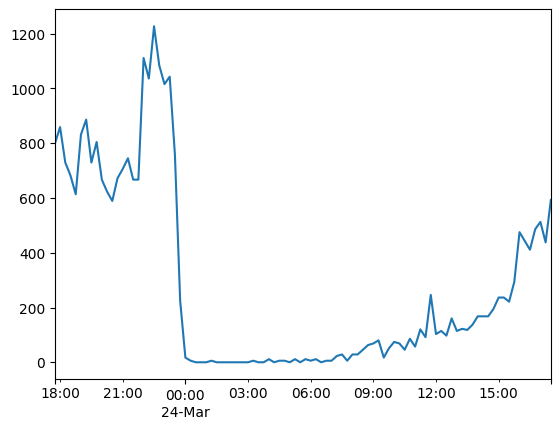

In [80]:
DATA_RAW_MODEL = pd.read_parquet(RAW_DATA_PATH)
DATA_RAW_MODEL = DATA_RAW_MODEL.resample(SAMPLING).mean()

## 8 Months history
DATA_RAW_MODEL = DATA_RAW_MODEL[DATA_RAW_MODEL.index.month.isin(DATA_RAW_MODEL.index.month.unique()[-MONTHS_HISTORY:])]
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[NODE_LIST]

display(DATA_RAW_MODEL)

if DEBUG:
    _sample_idx = randint(0,DATA_RAW_MODEL.shape[0])
    _sample = DATA_RAW_MODEL.iloc[_sample_idx: _sample_idx + int(24*60/SAMPLING_NUM)]
    _sample = _sample[DATA_RAW_MODEL.T.sample(1).index[0]]
    _sample.plot()


# PARAMETERS

In [97]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 10
LR = 0.001

# DATASET PARAMS#
#FREQ_MIN = 5
#FREQ_H = 12 #int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])

NUM_NODES = len(NODE_LIST)
HIST_STEPS = int(4*(24*60/SAMPLING_NUM))          # 4 day
PRED_STEPS = int(1*(24*60/SAMPLING_NUM))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 128


PATCH_LEN = 16
PATCH_STRIDE = 8


STEPS_PER_DAY = int(24*60/SAMPLING_NUM)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 4
D_HEADS = int(D_MODEL/K_HEADS)

print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEADS}")

Number of nodes: 16
Number of historical steps: 384
Number of prediction steps: 96
Number of time features: 115
Input dimension: 1
Output dimension: 1
Model dimension: 128
Steps per day: 96
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 4
Dimension of each head: 32


# DATASETS / DATALOADERS

In [98]:
class TimeSeriesDataset(Dataset):
    """
    A PyTorch Dataset for time series forecasting using sliding windows.
    """
    def __init__(self, data, seq_len, pred_len, stride=1):
        """
        Args:
            data (np.ndarray or torch.Tensor): The continuous time series data of shape (Total_Time_Steps, Channels).
            seq_len (int): The length of the look-back window (L).
            pred_len (int): The length of the prediction horizon (T).
            stride (int): How many steps to move the window forward for each sample. 
                          Use stride=1 for maximum data overlap (standard for training).
        """
        # Ensure data is a torch float32 tensor
        if isinstance(data, np.ndarray):
            self.data = torch.from_numpy(data.copy()).float()
        else:
            self.data = data.float()
            
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.stride = stride
        
        # Calculate how many valid windows we can extract
        self.num_samples = (len(self.data) - self.seq_len - self.pred_len) // self.stride + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        # Calculate the starting index of the sequence based on the stride
        start_idx = index * self.stride
        
        # End of the look-back window / Start of the prediction window
        end_idx = start_idx + self.seq_len
        
        # End of the prediction window
        pred_end_idx = end_idx + self.pred_len
        
        # Extract X (Input sequence) and Y (Target sequence)
        X = self.data[start_idx : end_idx, :]
        Y = self.data[end_idx : pred_end_idx, :]
        
        return X, Y



total_timesteps = DATA_RAW_MODEL.shape[0]
split_idx = int(total_timesteps * 0.8)
train_raw_data = DATA_RAW_MODEL.values[:split_idx]
val_raw_data = DATA_RAW_MODEL.values[split_idx - HIST_STEPS:]


TRAIN_DS = TimeSeriesDataset(train_raw_data, seq_len=HIST_STEPS, pred_len=PRED_STEPS)
VAL_DS = TimeSeriesDataset(val_raw_data, seq_len=HIST_STEPS, pred_len=PRED_STEPS)

TRAIN_DL = DataLoader(TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
VAL_DL = DataLoader(VAL_DS, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"TRAIN_DL: {len(TRAIN_DL)}")
print(f"VAL_DL: {len(VAL_DL)}")


if DEBUG:

    X,Y = next(iter(TRAIN_DL))
    print(f"X.shape: {X.shape}")
    print(f"Y.shape: {Y.shape}")

TRAIN_DL: 417
VAL_DL: 105
X.shape: torch.Size([32, 384, 16])
Y.shape: torch.Size([32, 96, 16])


# MODEL
## PATCHTST

In [99]:
class PatchTST(nn.Module):
    def __init__(self, seq_len, pred_len, patch_len=16, stride=8, 
                 d_model=128, n_heads=16, e_layers=3, d_ff=256, dropout=0.2):
        super().__init__()
        
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_len = patch_len
        self.stride = stride
        
        # Calculate the number of patches N = floor((L - P) / S) + 2
        # Padding by S repeated numbers of the last value adds an extra patch
        self.patch_num = int((seq_len - patch_len) / stride) + 2
        
        # Padding layer: pads the sequence with S repeated last values
        self.padding_patch_layer = nn.ReplicationPad1d((0, stride))
        
        # 1. Linear Projection (W_p)
        self.value_embedding = nn.Linear(patch_len, d_model)
        
        # 2. Positional Embedding (W_pos)
        self.position_embedding = nn.Parameter(torch.randn(1, self.patch_num, d_model))
        
        # 3. Transformer Encoder Backbone
        # Note: The paper mentions using BatchNorm instead of LayerNorm in the transformer 
        # blocks for time series, but standard PyTorch implementations use LayerNorm. 
        # We use the standard PyTorch LayerNorm-based TransformerEncoder here for simplicity.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_ff, 
            dropout=dropout, 
            activation='gelu', 
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=e_layers)
        
        # 4. Flatten and Linear Head for final forecasting
        self.head = nn.Linear(self.patch_num * d_model, pred_len)

    def forward(self, x):
        # Input shape: (Batch, Sequence_Length, Channels)
        B, L, M = x.shape
        
        # --- Instance Normalization ---
        # Normalize each univariate time series with zero mean and unit variance
        means = x.mean(dim=1, keepdim=True).detach()
        x = x - means
        stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + 1e-5).detach()
        x /= stdev
        
        # --- Channel-Independence ---
        # Permute to (Batch, Channels, Sequence_Length)
        x = x.permute(0, 2, 1) 
        
        # --- Patching ---
        # Pad S repeated numbers of the last value to the end of the original sequence
        x = self.padding_patch_layer(x)
        
        # Unfold sequence into patches. 
        # Shape becomes: (Batch, Channels, Num_Patches, Patch_Length)
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)
        
        # Fold the Batch and Channel dimensions together to process independently
        # Shape becomes: (Batch * Channels, Num_Patches, Patch_Length)
        x = x.reshape(B * M, self.patch_num, self.patch_len)
        
        # --- Projection & Positional Embedding ---
        x = self.value_embedding(x) + self.position_embedding
        
        # --- Transformer Encoder ---
        x = self.encoder(x)
        
        # --- Flattening & Linear Head ---
        # Flatten patches: (Batch * Channels, Num_Patches * d_model)
        x = x.reshape(B * M, -1)
        
        # Project to prediction length: (Batch * Channels, Prediction_Length)
        x = self.head(x)
        
        # --- Reshape back ---
        # Reshape to (Batch, Channels, Prediction_Length)
        x = x.reshape(B, M, self.pred_len)
        # Permute to (Batch, Prediction_Length, Channels)
        x = x.permute(0, 2, 1)
        
        # --- De-Normalization ---
        # Add the mean and variance back to the output prediction
        x = x * stdev
        x = x + means
        
        return x

if DEBUG:
    from random import randint

    stride = 8
    patch_len = 16
    seq_len = HIST_STEPS
    pred_len = PRED_STEPS
    
    e_layers = LAYERS_ENC_DEC
    d_ff = 256
    dropout = 0.2
    

    patch_num = int((seq_len - patch_len) / stride) + 2

    padding_patch_layer = nn.ReplicationPad1d((0, stride))
    value_embedding = nn.Linear(patch_len, D_MODEL)
    position_embedding = nn.Parameter(torch.randn(1, patch_num, D_MODEL))
    encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, 
            nhead=K_HEADS, 
            dim_feedforward=d_ff, 
            dropout=dropout, 
            activation='gelu', 
            batch_first=True
        )
    encoder = nn.TransformerEncoder(encoder_layer, num_layers=e_layers)
    head = nn.Linear(patch_num * D_MODEL, pred_len)

    for X,Y in TRAIN_DL:
        if randint(0,100) == 3:
            break

    print(f"X.shape: {X.shape}")
    print(f"Y.shape: {Y.shape}")

    B, L, M = X.shape
        

    means = X.mean(dim=1, keepdim=True).detach()
    print(f"means.shape: {means.shape}")

    X = X - means
    stdev = torch.sqrt(torch.var(X, dim=1, keepdim=True, unbiased=False) + 1e-5).detach()
    print(f"stdev.shape: {stdev.shape}")
    X /= stdev
    print()
    X = X.permute(0, 2, 1) 
    print(f"X.shape: {X.shape}")
    X = padding_patch_layer(X)
    print(f"X.shape after padding: {X.shape}")
    X = X.unfold(dimension=-1, size=patch_len, step=stride)
    print(f"X.shape after unfold: {X.shape}")
    X = X.reshape(B * M, patch_num, patch_len)
    print(f"X.shape after reshape: {X.shape}")
    X = value_embedding(X) + position_embedding
    print(f"X.shape after embedding: {X.shape}")
    X = encoder(X)
    print(f"X.shape after encoder: {X.shape}")
    X = X.reshape(B * M, -1)
    print(f"X.shape after reshape: {X.shape}")
    X = head(X)
    print(f"X.shape after head: {X.shape}")
    X = X.reshape(B, M, pred_len)
    print(f"X.shape after reshape: {X.shape}")
    X = X.permute(0, 2, 1)
    print(f"X.shape after permute: {X.shape}")

    X = X * stdev
    X = X + means
    print(f"X.shape after denormalization: {X.shape}")

X.shape: torch.Size([32, 384, 16])
Y.shape: torch.Size([32, 96, 16])
means.shape: torch.Size([32, 1, 16])
stdev.shape: torch.Size([32, 1, 16])

X.shape: torch.Size([32, 16, 384])
X.shape after padding: torch.Size([32, 16, 392])
X.shape after unfold: torch.Size([32, 16, 48, 16])
X.shape after reshape: torch.Size([512, 48, 16])
X.shape after embedding: torch.Size([512, 48, 128])
X.shape after encoder: torch.Size([512, 48, 128])
X.shape after reshape: torch.Size([512, 6144])
X.shape after head: torch.Size([512, 96])
X.shape after reshape: torch.Size([32, 16, 96])
X.shape after permute: torch.Size([32, 96, 16])
X.shape after denormalization: torch.Size([32, 96, 16])


# TRAINNIG

In [100]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {DEVICE}")

Training on: cuda


In [101]:
def train_model(model, train_loader, val_loader, epochs=10, learning_rate=1e-4, device='cuda'):
    """
    Trains the PatchTST model using MSE Loss.
    """
    model.to(device)
    
    # The paper uses MSE loss to measure the discrepancy between prediction and ground truth.
    # By default, nn.MSELoss() in PyTorch averages the loss across all elements (batch size, prediction length, and channels), 
    # which matches the paper's objective of gathering and averaging loss over the M time series.
    criterion = nn.MSELoss() 
    
    # Adam is a standard choice for Transformer-based architectures
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        total_train_loss = 0.0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # 1. Zero the gradients
            optimizer.zero_grad()
            
            # 2. Forward pass
            predictions = model(batch_x)
            
            # 3. Calculate loss
            loss = criterion(predictions, batch_y)
            
            # 4. Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item() * batch_x.size(0)
            
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        
        # --- Validation Phase ---
        model.eval()
        total_val_loss = 0.0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                
                predictions = model(batch_x)
                loss = criterion(predictions, batch_y)
                
                total_val_loss += loss.item() * batch_x.size(0)
                
        avg_val_loss = total_val_loss / len(val_loader.dataset)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss (MSE): {avg_train_loss:.4f} | Val Loss (MSE): {avg_val_loss:.4f}")

    return model

### TRAINING PROCESS

In [102]:
   
DIR_TRAINED = "TRAINED_MODELS"

## MODEL ZERO  (MSE ONLY)

In [103]:
MODEL = PatchTST(
        seq_len=HIST_STEPS, 
        pred_len=PRED_STEPS,
        patch_len=PATCH_LEN,
        stride=PATCH_STRIDE,
        d_model=D_MODEL,
        n_heads=K_HEADS,
        e_layers=LAYERS_ENC_DEC,
    ).to(DEVICE)



PREFIX_MODEL = 'patchtst_model_zero'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")


optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = nn.MSELoss()

Checkpoint path: TRAINED_MODELS/best_patchtst_model_zero.pth


In [104]:
MODEL = train_model(
    MODEL, 
    TRAIN_DL, 
    VAL_DL, 
    epochs=EPOCHS, 
    learning_rate=LR, 
    device=DEVICE
)



OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Epoch [1/10] | Train Loss (MSE): 40067.3376 | Val Loss (MSE): 10207.7916
Epoch [2/10] | Train Loss (MSE): 10067.9059 | Val Loss (MSE): 7117.0430
Epoch [3/10] | Train Loss (MSE): 7874.4383 | Val Loss (MSE): 6449.3773
Epoch [4/10] | Train Loss (MSE): 7013.3059 | Val Loss (MSE): 6118.3055
Epoch [5/10] | Train Loss (MSE): 6516.8959 | Val Loss (MSE): 5731.4585
Epoch [6/10] | Train Loss (MSE): 6137.0475 | Val Loss (MSE): 5394.8286
Epoch [7/10] | Train Loss (MSE): 5863.9195 | Val Loss (MSE): 4989.0116
Epoch [8/10] | Train Loss (MSE): 5661.8138 | Val Loss (MSE): 5116.5602
Epoch [9/10] | Train Loss (MSE): 5483.1164 | Val Loss (MSE): 4871.7331
Epoch [10/10] | Train Loss (MSE): 5371.9497 | Val Loss (MSE): 4799.6658
Model saved to TRAINED_MODELS/patchtst_model_zero_trained.pth


# VALIDATION MODELS

In [105]:

import math
import matplotlib.pyplot as plt

def validate_model(model, val_loader, device='cuda'):
    """
    Validates the time series forecasting model calculating MAE, RMSE, and MAPE.
    
    Args:
        model (nn.Module): The trained PyTorch model (e.g., PatchTST).
        val_loader (DataLoader): DataLoader containing the validation/test data.
        device (str): Device to run the validation on ('cuda' or 'cpu').
        
    Returns:
        tuple: (MAE, RMSE, MAPE)
    """
    # Ensure the model is in evaluation mode (disables dropout, etc.)
    model.eval()
    model.to(device)
    
    total_absolute_error = 0.0
    total_squared_error = 0.0
    total_percentage_error = 0.0
    
    # We count the total number of predicted elements across all batches, 
    # horizons, and channels to calculate an accurate global average.
    total_elements = 0 
    
    # Epsilon to prevent division by zero in MAPE calculation
    epsilon = 1e-7 

    # Disable gradient calculation for memory efficiency and speed
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # Get model predictions
            predictions = model(batch_x)
            
            # 1. Absolute Error (for MAE)
            abs_err = torch.abs(predictions - batch_y)
            total_absolute_error += torch.sum(abs_err).item()
            
            # 2. Squared Error (for RMSE)
            sq_err = torch.square(predictions - batch_y)
            total_squared_error += torch.sum(sq_err).item()
            
            # 3. Absolute Percentage Error (for MAPE)
            # We divide the absolute error by the absolute ground truth value
            abs_pct_err = abs_err / (torch.abs(batch_y) + epsilon)
            total_percentage_error += torch.sum(abs_pct_err).item()
            
            # Count elements in this batch (Batch_Size * Pred_Len * Channels)
            total_elements += batch_y.numel()

    # Calculate final aggregated metrics
    mae = total_absolute_error / total_elements
    rmse = math.sqrt(total_squared_error / total_elements)
    mape = (total_percentage_error / total_elements) * 100  # Convert to percentage

    print("-" * 30)
    print("Validation Results:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print("-" * 30)
    
    return mae, rmse, mape

def plot_random_channel_prediction(model, data_loader, device='cuda'):
    """
    Takes a single batch from the DataLoader, runs the model, picks a random 
    sample and a random channel, and plots the historical input, ground truth, and prediction.
    
    Args:
        model (nn.Module): The trained PyTorch model.
        data_loader (DataLoader): DataLoader containing the validation/test data.
        device (str): Device to run the inference on ('cuda' or 'cpu').
    """
    model.eval()
    model.to(device)
    
    # Grab one batch of data
    batch_x, batch_y = next(iter(data_loader))
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
    
    # Run the model to get predictions
    with torch.no_grad():
        predictions = model(batch_x)
        
    # Move tensors to CPU and convert to numpy for matplotlib
    batch_x = batch_x.cpu().numpy()
    batch_y = batch_y.cpu().numpy()
    predictions = predictions.cpu().numpy()
    
    # Get dimensions
    batch_size, seq_len, num_channels = batch_x.shape
    pred_len = batch_y.shape[1]
    
    # Select a random sample from the batch and a random channel
    sample_idx = randint(0, batch_size - 1)
    channel_idx = randint(0, num_channels - 1)
    
    # Extract the sequences for the selected sample and channel
    history = batch_x[sample_idx, :, channel_idx]
    truth = batch_y[sample_idx, :, channel_idx]
    pred = predictions[sample_idx, :, channel_idx]
    
    # Create x-axis time steps
    t_history = range(seq_len)
    t_future = range(seq_len, seq_len + pred_len)
    
    # --- Plotting ---
    # Clear the current plot just in case
    plt.clf()
    
    # Plot 1: Historical Data (Look-back window)
    plt.plot(t_history, history, label='Historical Input', color='#1f77b4')
    
    # Plot 2: Ground Truth Target (What actually happened)
    plt.plot(t_future, truth, label='Ground Truth', color='#2ca02c')
    
    # Plot 3: Model Prediction (What the model forecasted)
    plt.plot(t_future, pred, label='Model Prediction', color='#d62728', linestyle='--')
    
    # Formatting
    plt.title(f'Prediction vs Ground Truth\n(Sample Index: {sample_idx} | Channel Index: {channel_idx})')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)




### MODEL ZERO

Retrieving model from TRAINED_MODELS/patchtst_model_zero_trained.pth
------------------------------
Validation Results:
MAE:  40.0468
RMSE: 69.2897
MAPE: 522383572.0159%
------------------------------



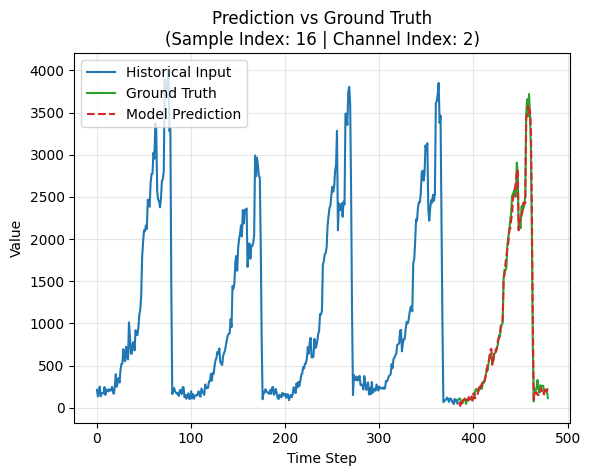

In [106]:
MODEL = PatchTST(
        seq_len=HIST_STEPS, 
        pred_len=PRED_STEPS,
        patch_len=PATCH_LEN,
        stride=PATCH_STRIDE,
        d_model=D_MODEL,
        n_heads=K_HEADS,
        e_layers=LAYERS_ENC_DEC,
    )



PREFIX_MODEL = 'patchtst_model_zero'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)


val_mae, val_rmse, val_mape = validate_model(MODEL, VAL_DL, device='cpu')

plot_random_channel_prediction(MODEL, VAL_DL, device='cpu')

print()

In [107]:
def validate_model_channel(model, val_loader, channel,  device=DEVICE):
    """
    Validates the time series forecasting model calculating MAE, RMSE, and MAPE.
    
    Args:
        model (nn.Module): The trained PyTorch model (e.g., PatchTST).
        val_loader (DataLoader): DataLoader containing the validation/test data.
        device (str): Device to run the validation on ('cuda' or 'cpu').
        
    Returns:
        tuple: (MAE, RMSE, MAPE)
    """
    # Ensure the model is in evaluation mode (disables dropout, etc.)
    model.eval()
    model.to(device)
    
    total_absolute_error = 0.0
    total_squared_error = 0.0
    #total_percentage_error = 0.0
    
    # We count the total number of predicted elements across all batches, 
    # horizons, and channels to calculate an accurate global average.
    total_elements = 0 
    
    # Epsilon to prevent division by zero in MAPE calculation
    epsilon = 1e-7 

    # Disable gradient calculation for memory efficiency and speed
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # Get model predictions
            predictions = model(batch_x)
            
            # 1. Absolute Error (for MAE)
            abs_err = torch.abs(predictions[channel] - batch_y[channel])
            total_absolute_error += torch.sum(abs_err).item()
            
            # 2. Squared Error (for RMSE)
            sq_err = torch.square(predictions[channel] - batch_y[channel])
            total_squared_error += torch.sum(sq_err).item()
            
            # 3. Absolute Percentage Error (for MAPE)
            # We divide the absolute error by the absolute ground truth value
            #abs_pct_err = abs_err / (torch.abs(batch_y[channel]) + epsilon)
            #total_percentage_error += torch.sum(abs_pct_err).item()
            
            # Count elements in this batch (Batch_Size * Pred_Len * Channels)
            total_elements += batch_y[channel].numel()

    # Calculate final aggregated metrics
    mae = total_absolute_error / total_elements
    rmse = math.sqrt(total_squared_error / total_elements)
    #mape = (total_percentage_error / total_elements) * 100  # Convert to percentage

    print("-" * 30)
    print("Validation Results:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    #print(f"MAPE: {mape:.4f}%")
    print("-" * 30)
    
    return mae, rmse#, mape


In [108]:
TABLE_RME = []
for i,node in enumerate(NODE_LIST):
    print(f"Node {i}: {node}")
    TABLE_RME.append(validate_model_channel(MODEL, VAL_DL,i))

TABLE_RME = pd.DataFrame(TABLE_RME, index=NODE_LIST, columns=['MAE','RMSE']).T.round(1)
TABLE_RME

Node 0: HR_A
------------------------------
Validation Results:
MAE:  42.1537
RMSE: 72.1883
------------------------------
Node 1: MR_A
------------------------------
Validation Results:
MAE:  42.3270
RMSE: 71.9955
------------------------------
Node 2: HR_B
------------------------------
Validation Results:
MAE:  40.9822
RMSE: 69.8758
------------------------------
Node 3: MR_B
------------------------------
Validation Results:
MAE:  40.5272
RMSE: 69.2564
------------------------------
Node 4: C
------------------------------
Validation Results:
MAE:  41.0209
RMSE: 70.6527
------------------------------
Node 5: D
------------------------------
Validation Results:
MAE:  40.3576
RMSE: 70.3284
------------------------------
Node 6: A
------------------------------
Validation Results:
MAE:  39.5565
RMSE: 68.3135
------------------------------
Node 7: B
------------------------------
Validation Results:
MAE:  40.0833
RMSE: 69.6752
------------------------------
Node 8: E
------------------

,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
MAE,42.2,42.3,41.0,40.5,41.0,40.4,39.6,40.1,40.8,41.3,40.5,39.6,39.1,38.5,38.0,38.7
RMSE,72.2,72.0,69.9,69.3,70.7,70.3,68.3,69.7,71.3,71.8,70.1,68.5,67.6,67.4,66.4,67.7


In [109]:
_output_excel = f'XLS_MODELS/{PREFIX_MODEL}_{SAMPLING}_table.csv'
_output_excel


'XLS_MODELS/patchtst_model_zero_15min_table.csv'

In [110]:
TABLE_RME.to_csv(_output_excel, sep=';')


# PREDICTION FUTURE

Current X shape: torch.Size([1, 384, 16])
Starting recursive prediction: 2880 steps total.
Model outputs 96 steps at a time -> Requires 30 iterations.


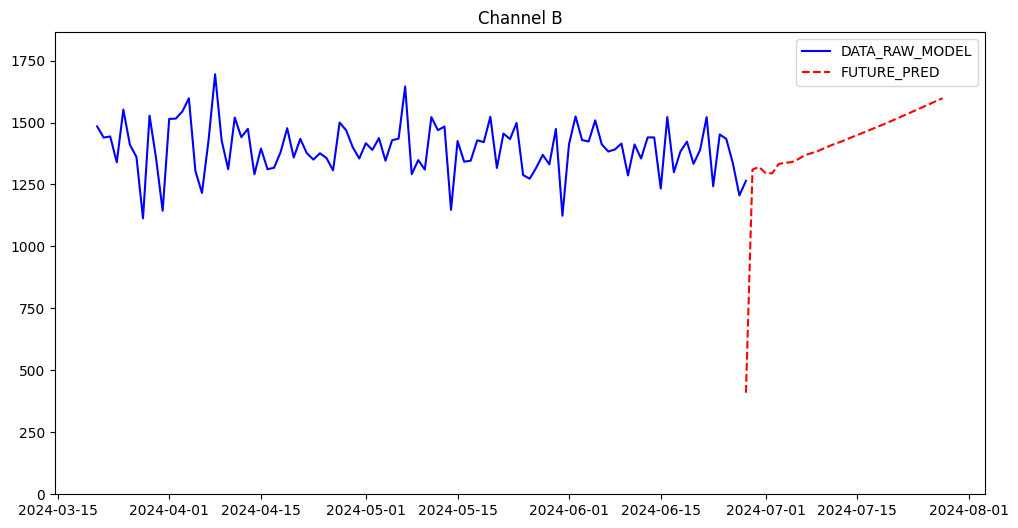

In [112]:

def predict_n_steps_future(model, dataloader, n_steps, device='cpu'):
    """
    Predicts N steps into the future recursively, starting from the last 
    available sequence in the dataloader.
    
    Args:
        model (nn.Module): The trained PyTorch model.
        dataloader (DataLoader): DataLoader containing the historical data.
        n_steps (int): Total number of future time steps to predict.
        device (str): Device to run inference on.
        
    Returns:
        numpy.ndarray: The predicted future values of shape (n_steps, num_channels).
    """
    model.eval()
    model.to(device)


    
    # 1. Get the very last sequence from the dataloader
    # We iterate through the whole loader to find the final batch
    last_batch_x, last_batch_y = None, None
    for batch_x, batch_y in dataloader:
        last_batch_x = batch_x
        last_batch_y = batch_y


    current_x = last_batch_x[-1:].to(device) 
    print(f"Current X shape: {current_x.shape}")
    
    # Determine lengths from the data
    seq_len = current_x.shape[1]
    pred_len = last_batch_y.shape[1]
    
    # Calculate how many iterations we need
    iterations = math.ceil(n_steps / pred_len)
    print(f"Starting recursive prediction: {n_steps} steps total.")
    print(f"Model outputs {pred_len} steps at a time -> Requires {iterations} iterations.")
    
    all_predictions = []
    
    # 2. Recursive Prediction Loop
    with torch.no_grad():
        for i in range(iterations):
            # Predict the next chunk
            # Output shape: (1, pred_len, num_channels)
       

            pred = model(current_x) 
            pred_real = pred

            # Store prediction (moved to CPU for later)
            all_predictions.append(pred_real)
            
            # Update the sliding window (current_x) for the next iteration
            # Concatenate the history and the new prediction along the time dimension (dim=1)
            combined_x = torch.cat((current_x, pred_real), dim=1)
            
            # Slice the combined tensor to keep only the most recent 'seq_len' steps
            current_x = combined_x[:, -seq_len:, :]
            
    # 3. Process and Trim Output
    # Concatenate all predicted chunks along the time dimension
    final_preds = torch.cat(all_predictions, dim=1)
    
    # Convert to numpy and drop the batch dimension: (Total_Predicted_Steps, Channels)
    final_preds_np = final_preds.squeeze(0).numpy()
    
    # Trim excess steps (since we predict in chunks of 'pred_len')
    final_preds_np = final_preds_np[:n_steps, :]
    
    return final_preds_np


OFFSET = DATA_RAW_MODEL.index[-1]
FUTURE_STEPS = 30*PRED_STEPS


FUTURE_PRED = pd.DataFrame(
    predict_n_steps_future(MODEL, VAL_DL, FUTURE_STEPS), 
    columns=NODE_LIST,
    index=pd.date_range(
        start=OFFSET,
        periods=FUTURE_STEPS,
        freq=SAMPLING
    )
)

rand_channel = choice(NODE_LIST)

plt.figure(figsize=(12, 6))
plt.plot(DATA_RAW_MODEL[rand_channel].resample('D').max().iloc[-100:], color='blue', linestyle='-', label='DATA_RAW_MODEL')
plt.plot(FUTURE_PRED[rand_channel].resample('D').max(), color='red', linestyle='--', label='FUTURE_PRED')
plt.title(f'Channel {rand_channel}')
plt.ylim(0, DATA_RAW_MODEL[rand_channel].max()*1.1)

plt.legend()
plt.show()